#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [2]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


In [2]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [4]:
def aep_powers(fi, df):
    power_list = []
    fi.reinitialize(
        layout_x=df["Layout_x"],
        layout_y=df['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

In [5]:
def plot_best_layouts(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)

    # Calculate and plot Convex Hull
    points = best_layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], 'k-')

    # Shade the area enclosed by the Convex Hull
    ax.fill(points[hull.vertices,0], points[hull.vertices,1], 'k', alpha=0.3)

In [8]:
def powers(fi, gen_1_pop):
    power_list = []
    fi.reinitialize(
        layout_x=gen_1_pop["Layout_x"],
        layout_y=gen_1_pop['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list


# nrel_p1_powers[]
# populations = initialize_populations()
# gen_1_pop = get_gen1_populations()

# for _ in range(len(gen_1_pop)):
#     nrel_p1_powers = powers(fi_vestas, gen_1_pop[_])
#     print(nrel_p1_powers)

# for _ in range(len(populations)):
#     nrel_p1_powers = powers(fi_nrel, populations[_])
#     print(nrel_p1_powers)
# nrel_p1_powers = powers(fi_nrel, gen_1_pop[0])
# nrel_p1_powers

In [6]:
data = {
    "Layout_y": [9846029.731, 9846197.111, 9846323.489, 9846423.521, 9846551.776, 9846743.266, 9846862.862, 9846981.229, 9847123.455, 9847380.825, 9847736.504, 9847881.979, 9847950.427, 9847815.822, 9848019.373, 9848107.184, 9847489.094, 9847936.821, 9847820.906, 9847734.012, 9847634.116, 9847532.026, 9847397.188, 9847256.911, 9847179.492, 9847312.767, 9847411.651, 9847536.334, 9847499.008, 9847518.827],
    "Layout_x": [2376.781, 2375.137, 2361.911, 2349.034, 2334.965, 2321.065, 2317.616, 2309.323, 2295.723, 2239.071, 2222.141, 2196.289, 2186.89, 2212.672, 2179.715, 2162.664, 2183.999, 2214.963, 2230.508, 2241.077, 2239.893, 2228.47, 2243.351, 2277.398, 2296.216, 2262.404, 2237.125, 2194.764, 2201.937, 2212.847]
}

df_actual = pd.DataFrame(data)

In [3]:
df_vestas = pd.read_csv('./pop_fav.csv')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


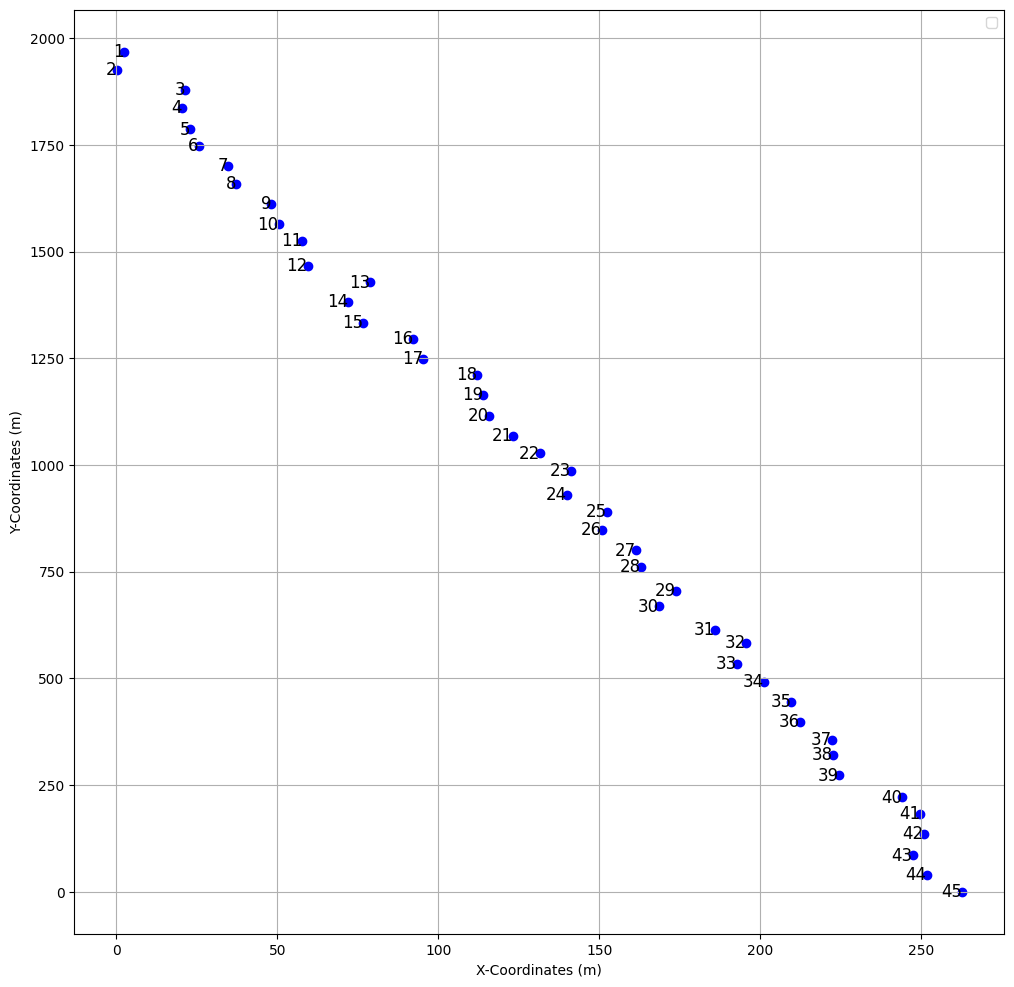

In [45]:
plt.figure(figsize=(12, 12))
plt.scatter(df_vestas['Layout_x'], df_vestas['Layout_y'], color='blue')
plt.grid(True)
# Add labels and title
plt.xlabel('X-Coordinates (m)')
plt.ylabel('Y-Coordinates (m)')
# plt.title('Scatter Plot')

# Add legend
plt.legend()

# Label each point with its index
for i, (x, y) in enumerate(zip(df_vestas['Layout_x'], df_vestas['Layout_y'])):
    plt.text(x, y, str(i+1), fontsize=12, ha='right', va='center')

# Show the plot
plt.show()

In [11]:
print(powers(fi_vestas, df_vestas))

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[77.24, 92.734, 16.708]


In [9]:
actual_powers = powers(fi_vestas, df_actual)
print(actual_powers)    

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[44.382, 61.823, 28.211]


In [4]:
df_nrel_13 = pd.read_csv('./gen_2_13.csv')

In [17]:
powers(fi_nrel, df_nrel_13)

[70.917, 86.978, 18.465]

In [22]:
yaw_angles = np.zeros([1,1,len(df_nrel_13)])

/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_deflection/gauss.py:342: RuntimeWarning: invalid value encountered in divide
  val = 2 * (avg_v - v_core) / (v_top + v_bottom)
/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_deflection/gauss.py:177: RuntimeWarning: invalid value encountered in divide
  C0 = 1 - u0 / freestream_velocity
/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_deflection/gauss.py:512: RuntimeWarning: invalid value encountered in divide
  I_total = np.sqrt((2 / 3) * k_total) / average_u_i
/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_velocity/gauss.py:91: RuntimeWarning: invalid value encountered in divide
  sigma_z0 = rotor_diameter_i * 0.5 * np.sqrt(uR / (u_initial + u0))


In [26]:
fi_nrel.reinitialize(wind_directions=[270.], wind_speeds=[8.0])

In [27]:
powers(fi_nrel, df_nrel_13)

[70.917, 86.978, 18.465]

In [31]:
fi_nrel.calculate_wake(yaw_angles=yaw_angles)

/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_deflection/gauss.py:342: RuntimeWarning: invalid value encountered in divide
  val = 2 * (avg_v - v_core) / (v_top + v_bottom)
/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_deflection/gauss.py:177: RuntimeWarning: invalid value encountered in divide
  C0 = 1 - u0 / freestream_velocity
/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_deflection/gauss.py:512: RuntimeWarning: invalid value encountered in divide
  I_total = np.sqrt((2 / 3) * k_total) / average_u_i
/home/codespace/.python/current/lib/python3.10/site-packages/floris/simulation/wake_velocity/gauss.py:91: RuntimeWarning: invalid value encountered in divide
  sigma_z0 = rotor_diameter_i * 0.5 * np.sqrt(uR / (u_initial + u0))


In [4]:
fi_vestas.reinitialize(
    layout_x=df_vestas["Layout_x"],
    layout_y=df_vestas['Layout_y'],
)
ws_array = np.arange(0,26,0.2)
fi_vestas.reinitialize(wind_speeds=ws_array)
# wd_array_1 = [270.0]
# fi_nrel.reinitialize(wind_speeds=ws_array_1)
# fi_nrel.calculate_wake(yaw_angles=yaw_angles)

In [14]:
len(fi_vestas.get_turbine_powers()[0][0])

45

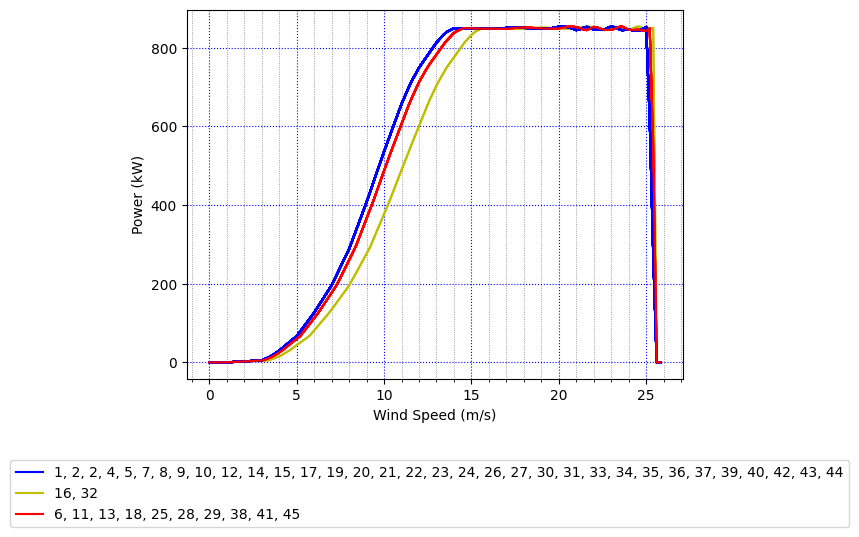

In [131]:
num_wd = 1
num_ws = len(ws_array)
num_turbine = len(df_vestas)
yaw_angles = np.zeros((num_wd, num_ws, num_turbine))

# Calculate
fi_vestas.calculate_wake(yaw_angles=yaw_angles)

# Collect the turbine powers
turbine_powers = fi_vestas.get_turbine_powers() / 1E3 # In kW

# Pull out the power values per turbine
pow_t0 = turbine_powers[:,:,0].flatten()
pow_t1 = turbine_powers[:,:,1].flatten()
pow_t2 = turbine_powers[:,:,2].flatten()
pow_t3 = turbine_powers[:,:,3].flatten()
pow_t4 = turbine_powers[:,:,4].flatten()
pow_t5 = turbine_powers[:,:,5].flatten()
pow_t6 = turbine_powers[:,:,6].flatten()
pow_t7 = turbine_powers[:,:,7].flatten()
pow_t8 = turbine_powers[:,:,8].flatten()
pow_t9 = turbine_powers[:,:,9].flatten()
pow_t10 = turbine_powers[:,:,10].flatten()
pow_t11 = turbine_powers[:,:,11].flatten()
pow_t12 = turbine_powers[:,:,12].flatten()
pow_t13 = turbine_powers[:,:,13].flatten()
pow_t14 = turbine_powers[:,:,14].flatten()
pow_t15 = turbine_powers[:,:,15].flatten()
pow_t16 = turbine_powers[:,:,16].flatten()
pow_t17 = turbine_powers[:,:,17].flatten()
pow_t18 = turbine_powers[:,:,18].flatten()
pow_t19 = turbine_powers[:,:,19].flatten()
pow_t20 = turbine_powers[:,:,20].flatten()
pow_t21 = turbine_powers[:,:,21].flatten()
pow_t22 = turbine_powers[:,:,22].flatten()
pow_t23 = turbine_powers[:,:,23].flatten()
pow_t24 = turbine_powers[:,:,24].flatten()
pow_t25 = turbine_powers[:,:,25].flatten()
pow_t26 = turbine_powers[:,:,26].flatten()
pow_t27 = turbine_powers[:,:,27].flatten()
pow_t28 = turbine_powers[:,:,28].flatten()
pow_t29 = turbine_powers[:,:,29].flatten()
pow_t30 = turbine_powers[:,:,30].flatten()
pow_t31 = turbine_powers[:,:,31].flatten()
pow_t32 = turbine_powers[:,:,32].flatten()
pow_t33 = turbine_powers[:,:,33].flatten()
pow_t34 = turbine_powers[:,:,34].flatten()
pow_t35 = turbine_powers[:,:,35].flatten()
pow_t36 = turbine_powers[:,:,36].flatten()
pow_t37 = turbine_powers[:,:,37].flatten()
pow_t38 = turbine_powers[:,:,38].flatten()
pow_t39 = turbine_powers[:,:,39].flatten()
pow_t40 = turbine_powers[:,:,40].flatten()
pow_t41 = turbine_powers[:,:,41].flatten()
pow_t42 = turbine_powers[:,:,42].flatten()
pow_t43 = turbine_powers[:,:,43].flatten()
pow_t44 = turbine_powers[:,:,44].flatten()

# Plot
# Plot
fig, ax = plt.subplots()
ax.plot(ws_array,pow_t0,color='b',label='1, 2, 2, 4, 5, 7, 8, 9, 10, 12, 14, 15, 17, 19, 20, 21, 22, 23, 24, 26, 27, 30, 31, 33, 34, 35, 36, 37, 39, 40, 42, 43, 44')
ax.plot(ws_array,pow_t1,color='b')
ax.plot(ws_array,pow_t2,color='b')
ax.plot(ws_array,pow_t3,color='b')
ax.plot(ws_array,pow_t4,color='b')
ax.plot(ws_array,pow_t15,color='y', label='16, 32')
ax.plot(ws_array,pow_t5,color='r',label='6, 11, 13, 18, 25, 28, 29, 38, 41, 45')
ax.plot(ws_array,pow_t6,color='b')
ax.plot(ws_array,pow_t7,color='b')
ax.plot(ws_array,pow_t8,color='b')
ax.plot(ws_array,pow_t9,color='b')
ax.plot(ws_array,pow_t10,color='r')
ax.plot(ws_array,pow_t11,color='b')
ax.plot(ws_array,pow_t12,color='r')
ax.plot(ws_array,pow_t13,color='b')
ax.plot(ws_array,pow_t14,color='b')
ax.plot(ws_array,pow_t16,color='b')
ax.plot(ws_array,pow_t17,color='r')
ax.plot(ws_array,pow_t18,color='b')
ax.plot(ws_array,pow_t19,color='b')
ax.plot(ws_array,pow_t20,color='b')
ax.plot(ws_array,pow_t21,color='b')
ax.plot(ws_array,pow_t22,color='b')
ax.plot(ws_array,pow_t23,color='b')
ax.plot(ws_array,pow_t24,color='r')
ax.plot(ws_array,pow_t25,color='b')
ax.plot(ws_array,pow_t26,color='b')
ax.plot(ws_array,pow_t27,color='r')
ax.plot(ws_array,pow_t28,color='r')
ax.plot(ws_array,pow_t29,color='b')
ax.plot(ws_array,pow_t30,color='b')
ax.plot(ws_array,pow_t31,color='y')
ax.plot(ws_array,pow_t32,color='b')
ax.plot(ws_array,pow_t33,color='b')
ax.plot(ws_array,pow_t34,color='b')
ax.plot(ws_array,pow_t35,color='b')
ax.plot(ws_array,pow_t36,color='b')
ax.plot(ws_array,pow_t37,color='r')
ax.plot(ws_array,pow_t38,color='b')
ax.plot(ws_array,pow_t39,color='b')
ax.plot(ws_array,pow_t40,color='r')
ax.plot(ws_array,pow_t41,color='b')
ax.plot(ws_array,pow_t42,color='b')
ax.plot(ws_array,pow_t43,color='b')
ax.plot(ws_array,pow_t44,color='r')


# ax.grid(True)
plt.grid(which='major', linestyle=':', linewidth='0.8', color='blue')
# plt.grid(which='minor', linestyle=':', linewidth='0.5', color='red')
# Add labels to each line
lines, labels = ax.get_legend_handles_labels()
unique_labels = list(set(labels))
unique_labels.sort()

# Create a single legend with labels underneath the duplicate lines
ax.legend(lines, unique_labels, loc='upper right', bbox_to_anchor=(1.35, -0.2))

ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')

plt.grid(which='minor', linestyle=':', linewidth='0.6', color='gray', axis='x')  # Minor gridlines on x-axis only
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(1))

plt.show()

In [8]:
from floris.tools.layout_functions import visualize_layout


In [10]:
len(df_vestas)

45

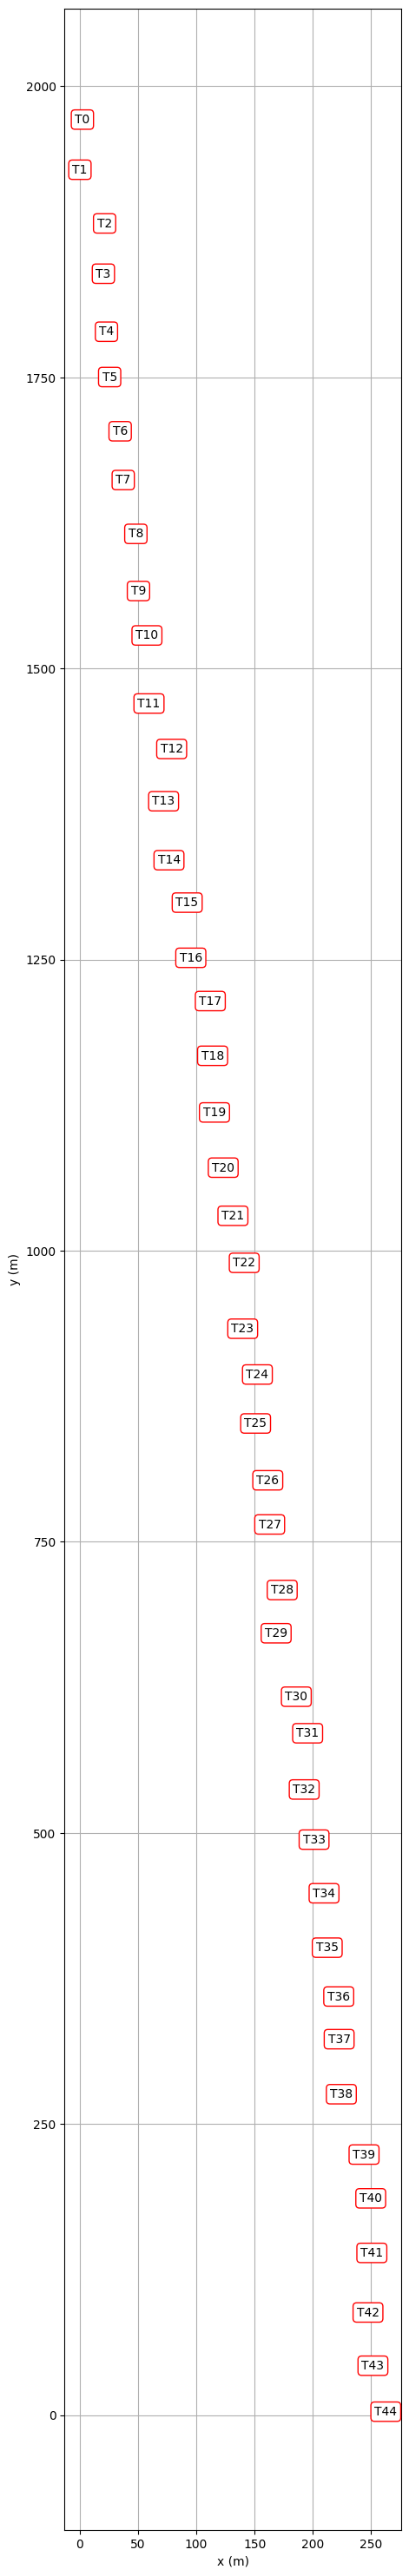

In [34]:
turbine_names = ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27', 'T28', 'T29', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T36', 'T37', 'T38', 'T39', 'T40', 'T41', 'T42', 'T43', 'T44']
fig, ax = plt.subplots(figsize=(5, 100))

# visualize_layout(fi_vestas, ax=ax)
ax.grid(True)  # Add gridlines

# ax.set_title('Default visualization')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
visualize_layout(
    fi_vestas,
    ax=ax,
    # show_wake_lines=True,
    # lim_lines_per_turbine=2,
    turbine_names=turbine_names,
        
)

# plt.figure(figsize=(12, 12))
# plt.scatter(df_vestas['Layout_x'], df_vestas['Layout_y'], color='blue')
# plt.grid(True)
# Add labels and title
# plt.xlabel('X-Coordinates (m)')
# plt.ylabel('Y-Coordinates (m)')
# plt.title('Scatter Plot')

# Add legend
# plt.legend()

# Show the plot
plt.show()